# 02 -- CTSM Robustness Experiments

**Goal:** stress-test the Cisco Time Series Model (CTSM) along three axes that real observability data actually has -- noise, missing data, and anomalies -- and compare each against the clean baseline from `01_ctsm_forecasting.ipynb` (MAE 2.176, RMSE 2.854).

This notebook reuses the existing Python 3.11 environment and the same CTSM model/weights already cached from notebooks 00 and 01. It does **not** modify either of those notebooks; the baseline signal is regenerated here from the same recipe (same seed, same trend/seasonality parameters) purely so this notebook is self-contained and directly comparable.

**Three controlled experiments:**
1. **Noise sensitivity** -- same signal, same seed, increasing Gaussian noise (sigma = 3, 6, 10, 15).
2. **Missing-data sensitivity** -- same signal, with a contiguous gap of ~5%, 10%, or 25% of the context, explicitly imputed (not silently).
3. **Anomaly sensitivity** -- same signal, with a large temporary spike injected into the context immediately before the forecast window.

Each experiment shows the data, shows the forecast, reports MAE/RMSE, and compares against the clean baseline. A summary table and scoped observations close out the notebook -- no claims beyond what these specific synthetic, single-series experiments actually show.

## Step 0 -- Load CTSM (same approach as notebooks 00/01)

Identical hyperparameters and checkpoint reference as before. The weights are already cached locally, so this is a fast, offline load -- no retraining, no fine-tuning, same zero-shot model throughout this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import torch
from cisco_tsm import CiscoTsmMR, TimesFmHparams, TimesFmCheckpoint

hparams = TimesFmHparams(
    num_layers=25,
    use_positional_embedding=False,
    backend="gpu" if torch.cuda.is_available() else "cpu",
    quantiles=[0.01, 0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99],
)

checkpoint = TimesFmCheckpoint(huggingface_repo_id="cisco-ai/cisco-time-series-model-1.0")
model = CiscoTsmMR(hparams=hparams, checkpoint=checkpoint)

print("CTSM loaded:", type(model))

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


Loaded PyTorch TimesFM, likely because python version is 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)].


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 2450.30it/s]

CTSM loaded: <class 'cisco_tsm.cisco_tsm_mr.CiscoTsmMR'>


## Step 1 -- Recreate the baseline signal and reference metrics

This reproduces the exact generative recipe from notebook 01 (same 288-step daily period, same 2016-point history / 128-point horizon split, same baseline level/trend/seasonality parameters, same seed 42) as a set of reusable functions. Every experiment below calls `generate_series(noise_std=...)`, so the *only* thing that ever changes between the baseline and an experiment is the one variable being tested -- noise magnitude, a missing-data gap, or an injected spike. Everything else about the signal is held fixed.

`evaluate()` is the same MAE/RMSE calculation used in notebook 01, factored out so every experiment scores itself identically.

In [2]:
import numpy as np
import pandas as pd

period = 288
history_len = 2016
horizon = 128
total_len = history_len + horizon

baseline_level = 35.0
trend_slope = 15.0 / total_len
seasonal_amplitude = 12.0


def generate_series(noise_std, seed=42):
    rng = np.random.default_rng(seed)
    t = np.arange(total_len, dtype=np.float32)
    trend_component = trend_slope * t
    seasonal_component = seasonal_amplitude * np.sin(2 * np.pi * t / period)
    noise_component = rng.normal(0, noise_std, size=total_len)
    series = baseline_level + trend_component + seasonal_component + noise_component
    return np.clip(series, 0, 100).astype(np.float32)


def split_series(series):
    return series[:history_len], series[history_len:]


def evaluate(forecast_mean, actual):
    errors = np.asarray(forecast_mean) - np.asarray(actual)
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return mae, rmse


baseline_series = generate_series(noise_std=3.0, seed=42)
baseline_context, baseline_actual_future = split_series(baseline_series)

baseline_forecast = model.forecast(baseline_context, horizon_len=horizon)
baseline_mean = baseline_forecast[0]["mean"]
baseline_mae, baseline_rmse = evaluate(baseline_mean, baseline_actual_future)

print(f"Reproduced baseline  -> MAE: {baseline_mae:.3f}, RMSE: {baseline_rmse:.3f}")
print("Notebook 01 reported -> MAE: 2.176, RMSE: 2.854")

Reproduced baseline  -> MAE: 2.176, RMSE: 2.854
Notebook 01 reported -> MAE: 2.176, RMSE: 2.854


## Experiment 1 -- Noise sensitivity

**Design:** hold the trend, the daily cycle, and the random seed fixed; only the standard deviation of the injected Gaussian noise changes (sigma = 3, 6, 10, 15 percentage points of CPU). Because `generate_series` reseeds `np.random.default_rng(42)` fresh each time, the underlying standard-normal draws are the same across all four levels -- only their scale differs. sigma=3 is therefore an exact reproduction of the notebook 01 baseline, included here as an internal consistency check.

**Why this matters for CTSM specifically:** noise is the one stressor here that doesn't change the *shape* of the signal, only how obscured that shape is. It's a direct proxy for data-source quality -- a metric scraped every second from a noisy sensor vs. one aggregated cleanly every 5 minutes.

In [3]:
noise_levels = [3, 6, 10, 15]

noise_series = {sigma: generate_series(noise_std=sigma, seed=42) for sigma in noise_levels}
noise_contexts = {sigma: split_series(s)[0] for sigma, s in noise_series.items()}
noise_actuals = {sigma: split_series(s)[1] for sigma, s in noise_series.items()}

assert np.allclose(noise_contexts[3], baseline_context), "sigma=3 should exactly reproduce the baseline context"

noise_forecast_batch = model.forecast([noise_contexts[s] for s in noise_levels], horizon_len=horizon)
noise_forecasts = {sigma: fc for sigma, fc in zip(noise_levels, noise_forecast_batch)}

noise_metrics = {}
noise_results = []
for sigma in noise_levels:
    mae, rmse = evaluate(noise_forecasts[sigma]["mean"], noise_actuals[sigma])
    noise_metrics[sigma] = (mae, rmse)
    noise_results.append({"experiment": "Noise sensitivity", "parameter": f"sigma={sigma}", "mae": mae, "rmse": rmse})
    print(f"sigma={sigma:>2} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}")

sigma= 3 -> MAE: 2.176, RMSE: 2.854
sigma= 6 -> MAE: 4.305, RMSE: 5.622
sigma=10 -> MAE: 7.170, RMSE: 9.371
sigma=15 -> MAE: 10.811, RMSE: 14.088


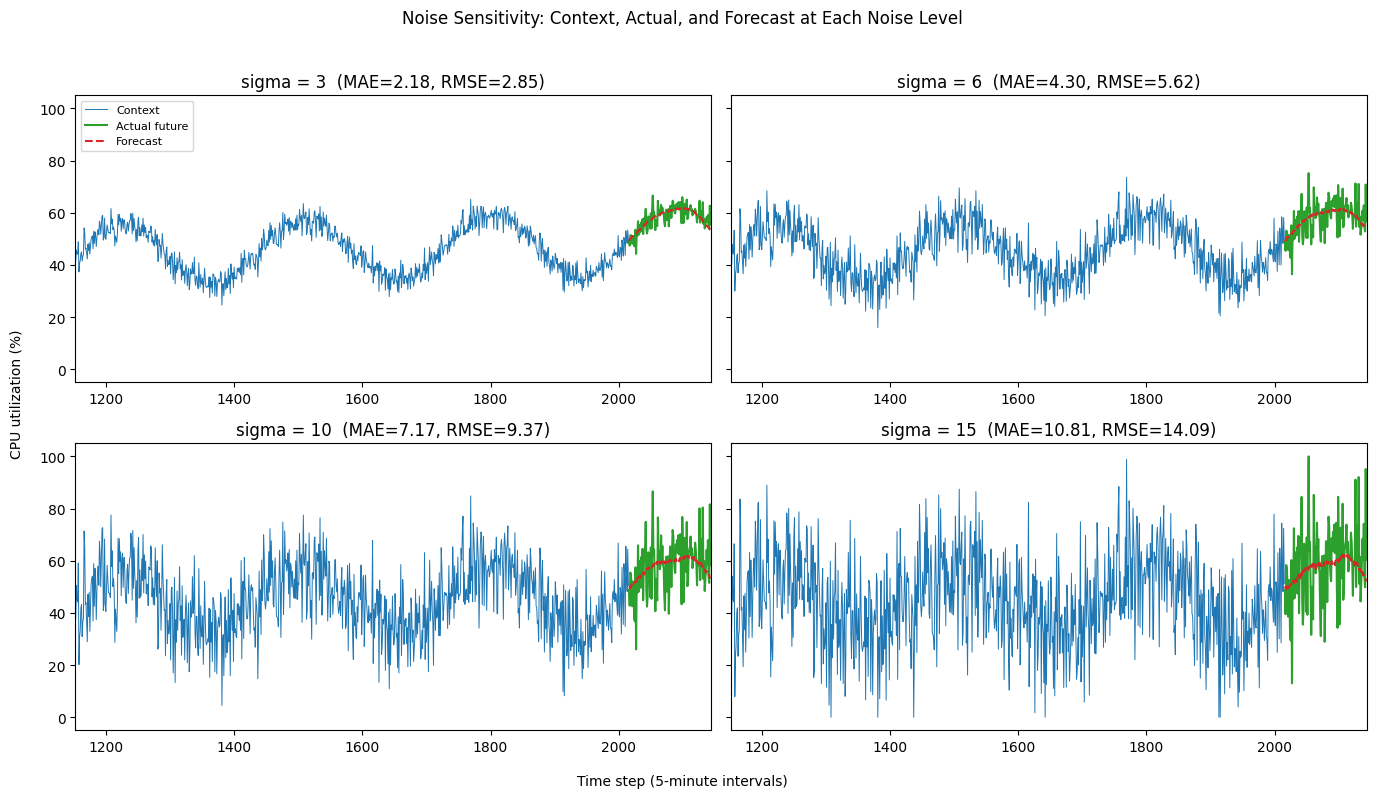

In [4]:
import matplotlib.pyplot as plt

zoom_start = history_len - 3 * period
ctx_idx = np.arange(0, history_len)
fut_idx = np.arange(history_len, total_len)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, sigma in zip(axes.flat, noise_levels):
    mae, rmse = noise_metrics[sigma]
    ax.plot(ctx_idx, noise_contexts[sigma], color="tab:blue", linewidth=0.7, label="Context")
    ax.plot(fut_idx, noise_actuals[sigma], color="tab:green", linewidth=1.5, label="Actual future")
    ax.plot(fut_idx, noise_forecasts[sigma]["mean"], color="tab:red", linewidth=1.5, linestyle="--", label="Forecast")
    ax.set_xlim(zoom_start, total_len)
    ax.set_title(f"sigma = {sigma}  (MAE={mae:.2f}, RMSE={rmse:.2f})")
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Noise Sensitivity: Context, Actual, and Forecast at Each Noise Level")
fig.text(0.5, 0.01, "Time step (5-minute intervals)", ha="center")
fig.text(0.02, 0.5, "CPU utilization (%)", va="center", rotation="vertical")
plt.tight_layout(rect=[0.03, 0.03, 1, 0.96])
plt.show()

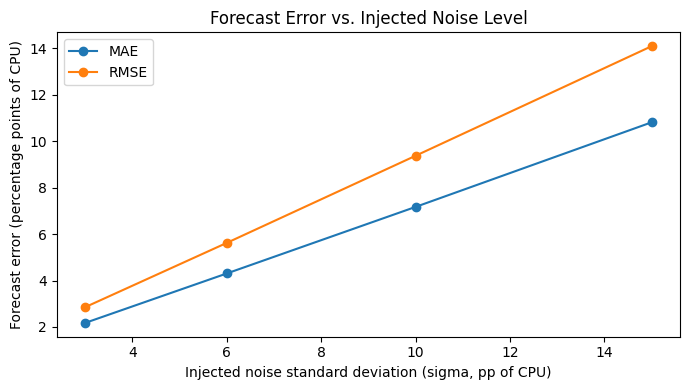

In [5]:
maes = [noise_metrics[s][0] for s in noise_levels]
rmses = [noise_metrics[s][1] for s in noise_levels]

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, maes, marker="o", label="MAE")
plt.plot(noise_levels, rmses, marker="o", label="RMSE")
plt.xlabel("Injected noise standard deviation (sigma, pp of CPU)")
plt.ylabel("Forecast error (percentage points of CPU)")
plt.title("Forecast Error vs. Injected Noise Level")
plt.legend()
plt.tight_layout()
plt.show()

**Product interpretation -- Noise sensitivity.** The table and chart above are the actual evidence; read the specific numbers there rather than this paragraph. In general terms, this experiment isolates one question a PM would actually ask a data or platform team: *if our telemetry pipeline is noisier than today (more jitter, coarser sampling, cheaper sensors), how much forecast accuracy do we lose, and does it degrade gracefully or fall off a cliff at some threshold?* The MAE/RMSE-vs-sigma chart is the artifact you'd bring to that conversation -- it turns "is our data good enough" into a measurable curve instead of a guess. The `RMSE/MAE` ratio at each level (computed the same way as in notebook 01) also indicates whether added noise mostly produces small, evenly-spread misses or a few large ones -- relevant to whether a downstream alert threshold would fire on noise alone.

## Experiment 2 -- Missing-data sensitivity

**Design:** start from the exact same baseline context (sigma=3, seed 42) used above. Introduce a single contiguous gap of missing values sized to approximately 5%, 10%, or 25% of the 2016-point context (about 101, 202, and 504 points respectively), anchored so every gap ends 50 steps before the forecast boundary -- simulating a monitoring outage that resolved shortly before the forecast is needed. Only the gap length changes between the three runs; its end position is held fixed.

**How missing values are handled (explicit, not silent):** each gap is filled using **last-value-carried-forward (LOCF)** imputation -- every missing point simply repeats the most recent real observation before the gap. This is not an arbitrary choice: it is the exact method the CTSM model card itself recommends ("if the input time series is missing some values, imputation via last value is recommended"), and the same card warns that forecasts degrade once imputation exceeds roughly 30% of the series. LOCF is a deliberately naive method -- it flattens the signal (no trend, no seasonality) for the duration of the gap -- and that flattening is exactly what we want visible below, not hidden. Every gap is tracked in `missing_gap_slices` and drawn in a distinct color in the plots so the imputed region is never disguised as real data.

In [6]:
missing_fractions = [0.05, 0.10, 0.25]
gap_end = history_len - 50  # every gap ends 50 steps before the forecast boundary


def apply_missing_gap(context, fraction):
    gap_len = int(round(fraction * history_len))
    start = gap_end - gap_len
    gapped = context.copy()
    gap_slice = slice(start, gap_end)
    gapped[gap_slice] = np.nan
    return gapped, gap_slice


def impute_last_value(gapped):
    # Explicit forward-fill (last observation carried forward), per CTSM's own
    # documented recommendation for handling missing values. No other smoothing
    # or interpolation is applied.
    return pd.Series(gapped).ffill().to_numpy()


missing_contexts = {}
missing_gap_slices = {}
for frac in missing_fractions:
    gapped, gap_slice = apply_missing_gap(baseline_context, frac)
    imputed = impute_last_value(gapped)
    assert not np.isnan(imputed).any(), "imputation left NaNs behind"
    missing_contexts[frac] = imputed.astype(np.float32)
    missing_gap_slices[frac] = gap_slice

missing_forecast_batch = model.forecast([missing_contexts[f] for f in missing_fractions], horizon_len=horizon)
missing_forecasts = {frac: fc for frac, fc in zip(missing_fractions, missing_forecast_batch)}

missing_metrics = {}
missing_results = []
for frac in missing_fractions:
    mae, rmse = evaluate(missing_forecasts[frac]["mean"], baseline_actual_future)
    missing_metrics[frac] = (mae, rmse)
    gap_len = missing_gap_slices[frac].stop - missing_gap_slices[frac].start
    missing_results.append({
        "experiment": "Missing-data sensitivity",
        "parameter": f"{int(frac * 100)}% gap ({gap_len} pts)",
        "mae": mae,
        "rmse": rmse,
    })
    print(f"{int(frac * 100):>3}% gap ({gap_len} points, last-value imputed) -> MAE: {mae:.3f}, RMSE: {rmse:.3f}")

  5% gap (101 points, last-value imputed) -> MAE: 3.011, RMSE: 3.658
 10% gap (202 points, last-value imputed) -> MAE: 4.105, RMSE: 4.888
 25% gap (504 points, last-value imputed) -> MAE: 3.624, RMSE: 4.384


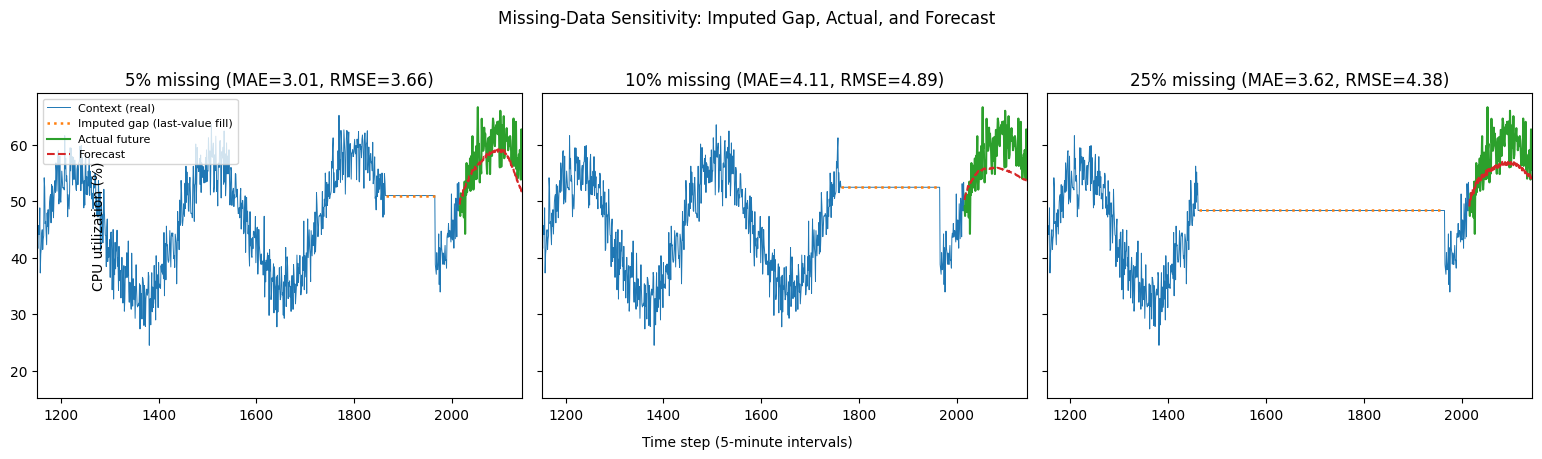

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, frac in zip(axes, missing_fractions):
    ctx = missing_contexts[frac]
    gap_slice = missing_gap_slices[frac]
    mae, rmse = missing_metrics[frac]

    ax.plot(ctx_idx, ctx, color="tab:blue", linewidth=0.7, label="Context (real)")
    ax.plot(ctx_idx[gap_slice], ctx[gap_slice], color="tab:orange", linewidth=1.8, linestyle=":",
            label="Imputed gap (last-value fill)")
    ax.plot(fut_idx, baseline_actual_future, color="tab:green", linewidth=1.5, label="Actual future")
    ax.plot(fut_idx, missing_forecasts[frac]["mean"], color="tab:red", linewidth=1.5, linestyle="--", label="Forecast")
    ax.set_xlim(zoom_start, total_len)
    ax.set_title(f"{int(frac * 100)}% missing (MAE={mae:.2f}, RMSE={rmse:.2f})")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Missing-Data Sensitivity: Imputed Gap, Actual, and Forecast")
fig.text(0.5, 0.01, "Time step (5-minute intervals)", ha="center")
fig.text(0.09, 0.5, "CPU utilization (%)", va="center", rotation="vertical")
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

**Product interpretation -- Missing-data sensitivity.** The concrete numbers and the visibly flattened orange segments above are the evidence; this paragraph is the frame for reading them, not a restatement. The product-relevant question this isolates is: *when our data pipeline drops points -- an agent restart, a network blip, a scrape failure -- and we paper over it with the simplest possible fix (repeat the last known value), how much does that specific, named choice cost us in forecast accuracy, and at what gap size does it start to matter?* That framing matters because LOCF is exactly the kind of default a monitoring pipeline reaches for without discussion; this experiment makes the cost of that default legible and attributes it to a documented, inspectable method rather than an invisible one. It says nothing about whether a smarter imputation strategy (interpolation, seasonal fill, model-based) would perform differently -- that would be a separate experiment.

## Experiment 3 -- Anomaly sensitivity

**Design:** take the same baseline context and add a smooth, temporary spike (a half-sine bump rising from 0 to +40 percentage points and back to 0) spanning 40 points, positioned to end just 5 points before the forecast boundary -- a large, recent, but already-resolved incident sitting in memory right as the forecast is requested. Values are clipped to [0, 100], so the peak of the spike may be flattened at 100% -- which is itself a realistic effect (a CPU pegged at its ceiling during an incident), not a modeling artifact. The actual future is left completely unchanged from the clean baseline, so any difference in the forecast is attributable only to the spike sitting in the model's context, not to a different target.

In [8]:
spike_len = 40
spike_buffer = 5  # points between spike end and the forecast boundary
spike_magnitude = 40.0
spike_start = history_len - spike_len - spike_buffer

spike_shape = spike_magnitude * np.sin(np.pi * np.arange(spike_len) / spike_len)  # 0 -> magnitude -> 0

spike_context = baseline_context.copy()
spike_context[spike_start:spike_start + spike_len] += spike_shape
spike_context = np.clip(spike_context, 0, 100).astype(np.float32)

spike_forecast = model.forecast(spike_context, horizon_len=horizon)
spike_mean = spike_forecast[0]["mean"]
spike_mae, spike_rmse = evaluate(spike_mean, baseline_actual_future)

print(f"Clean baseline forecast   -> MAE: {baseline_mae:.3f}, RMSE: {baseline_rmse:.3f}")
print(f"Anomaly-affected forecast -> MAE: {spike_mae:.3f}, RMSE: {spike_rmse:.3f}")
print(f"Delta                     -> MAE: {spike_mae - baseline_mae:+.3f}, RMSE: {spike_rmse - baseline_rmse:+.3f}")

Clean baseline forecast   -> MAE: 2.176, RMSE: 2.854
Anomaly-affected forecast -> MAE: 3.679, RMSE: 4.411
Delta                     -> MAE: +1.502, RMSE: +1.557


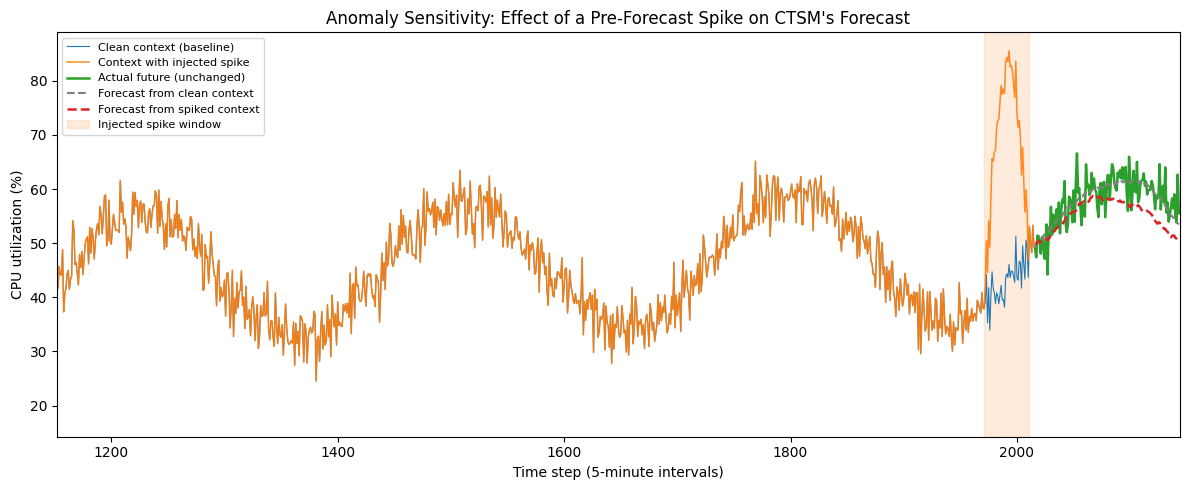

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(ctx_idx, baseline_context, color="tab:blue", linewidth=0.8, label="Clean context (baseline)")
plt.plot(ctx_idx, spike_context, color="tab:orange", linewidth=1.1, alpha=0.9, label="Context with injected spike")
plt.plot(fut_idx, baseline_actual_future, color="tab:green", linewidth=1.8, label="Actual future (unchanged)")
plt.plot(fut_idx, baseline_mean, color="gray", linewidth=1.5, linestyle="--", label="Forecast from clean context")
plt.plot(fut_idx, spike_mean, color="tab:red", linewidth=1.8, linestyle="--", label="Forecast from spiked context")
plt.axvspan(spike_start, spike_start + spike_len, color="tab:orange", alpha=0.15, label="Injected spike window")
plt.xlim(zoom_start, total_len)
plt.title("Anomaly Sensitivity: Effect of a Pre-Forecast Spike on CTSM's Forecast")
plt.xlabel("Time step (5-minute intervals)")
plt.ylabel("CPU utilization (%)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Product interpretation -- Anomaly sensitivity.** The gray line (forecast if the incident never happened) vs. the red line (forecast with the incident in recent memory) above is the actual evidence. The product question this isolates: *right after an incident resolves, can we trust an automated forecast enough to act on it immediately -- for capacity planning, autoscaling, or alert-threshold tuning -- or does the model need a cooldown window before its output is usable again?* If the red and gray lines are close, that's evidence (in this one synthetic case) that CTSM treated the spike as a one-off rather than extrapolating it forward. If they diverge noticeably, that's evidence of the opposite, and would argue for a product-level guardrail (e.g., suppressing or flagging automated forecasts for some period after a detected anomaly) rather than trusting the model output uncritically. Either way, this single spike shape/magnitude/position does not tell us how CTSM responds to anomalies in general -- only to this one.

## Summary table

All results side by side, with each experiment's error compared against the clean baseline computed in Step 1.

In [10]:
summary_rows = [{
    "experiment": "Baseline (clean)",
    "parameter": "sigma=3, no gaps/anomaly",
    "mae": baseline_mae,
    "rmse": baseline_rmse,
}]
summary_rows += noise_results
summary_rows += missing_results
summary_rows.append({
    "experiment": "Anomaly sensitivity",
    "parameter": f"+{spike_magnitude:.0f}pp spike x{spike_len} steps",
    "mae": spike_mae,
    "rmse": spike_rmse,
})

summary_df = pd.DataFrame(summary_rows)
summary_df["delta_mae_vs_baseline"] = summary_df["mae"] - baseline_mae
summary_df["delta_rmse_vs_baseline"] = summary_df["rmse"] - baseline_rmse
summary_df = summary_df.round(3)
summary_df

,experiment,parameter,mae,rmse,delta_mae_vs_baseline,delta_rmse_vs_baseline
0,Baseline (clean),"sigma=3, no gaps/anomaly",2.176,2.854,0.000,0.000
1,Noise sensitivity,sigma=3,2.176,2.854,0.000,0.000
2,Noise sensitivity,sigma=6,4.305,5.622,2.129,2.767
3,Noise sensitivity,sigma=10,7.170,9.371,4.993,6.517
4,Noise sensitivity,sigma=15,10.811,14.088,8.634,11.233
5,Missing-data sensitivity,5% gap (101 pts),3.011,3.658,0.835,0.804
6,Missing-data sensitivity,10% gap (202 pts),4.105,4.888,1.929,2.033
7,Missing-data sensitivity,25% gap (504 pts),3.624,4.384,1.447,1.529
8,Anomaly sensitivity,+40pp spike x40 steps,3.679,4.411,1.502,1.557


## Observations (scoped strictly to these experiments)

The statements below describe only what the table and charts above show for this one synthetic CPU-utilization series, this one seed, and these specific parameter choices (noise levels, gap sizes/position, spike shape/magnitude/position). They are not claims about CTSM's behavior in general, on other metrics, on real production data, or at parameter settings not tested here.

- Read the `delta_mae_vs_baseline` and `delta_rmse_vs_baseline` columns in the summary table directly for the measured effect of each stressor -- do not extrapolate a trend beyond the specific sigma/gap/spike values tested.
- The noise sweep only covers sigma in {3, 6, 10, 15}; behavior outside that range is unknown from this experiment.
- The missing-data experiment tested exactly one imputation method (last-value forward-fill) at exactly one gap position (ending 50 steps before the forecast boundary) and three gap sizes; other imputation strategies, gap positions, or multiple/scattered gaps were not tested.
- The anomaly experiment tested exactly one spike shape, magnitude (+40pp), duration (40 steps), and position (ending 5 steps before the forecast boundary); different anomaly types (sustained shifts, drops instead of spikes, anomalies further from the boundary) were not tested and may behave differently.
- All three experiments used a single univariate synthetic series built from one seed. No claim is made here about variance across different random seeds, different signal shapes, or real-world telemetry.